In [1]:
!pip install gplearn


Training from 2017-03-02 to 2023-12-25
Testing  from 2024-01-25 to 2025-02-21
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left


<ipython-input-2-364b01592b52>:66: RuntimeWarning: divide by zero encountered in log
  return np.where(x > 0, np.log(x), 0.0)
<ipython-input-2-364b01592b52>:66: RuntimeWarning: invalid value encountered in log
  return np.where(x > 0, np.log(x), 0.0)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
<ipython-input-2-364b01592b52>:66: RuntimeWarning: divide by zero encountered in log
  return np.where(x > 0, np.log(x), 0.0)
<ipython-input-2-364b01592b52>:72: RuntimeWarning: overflow encountered in exp
  return np.where(x < 100, np.exp(x), 0.0)
<ipython-input-2-364b01592b52>:66: RuntimeWarning: invalid value encountered in log
  return np.where(x > 0, np.log(x), 0.0)
/usr/local/lib/python3.11/dist-packages/gplearn/functions.py:127: Runtime

   0     8.45       4.3857e+41        3          1174.88          1339.97      1.21m
   1     6.14      6.74652e+40        3          1170.18          1382.31      1.16m
   2     4.36      5.96879e+38        4          1158.51          1502.51      1.04m
   3     3.33      1.28392e+44        1           1151.7          1548.36     57.46s
   4     3.09        7.497e+37        3          1151.91          1546.62     54.03s
   5     2.96      8.28102e+37        5          1153.66          1529.95     52.99s
   6     2.93      2.09886e+39        1          1153.07             1536     52.03s
   7     2.77      2.41879e+38        1          1158.79          1484.55      1.08m
   8     2.47      1.64905e+38        1          1146.35          1596.44      1.34m
   9     2.31      2.98996e+38        1          1151.45          1550.61     46.40s
  10     2.32      4.84187e+38        1          1149.38          1569.25     45.75s
  11     2.02      2.70181e+38        3          1157.09         

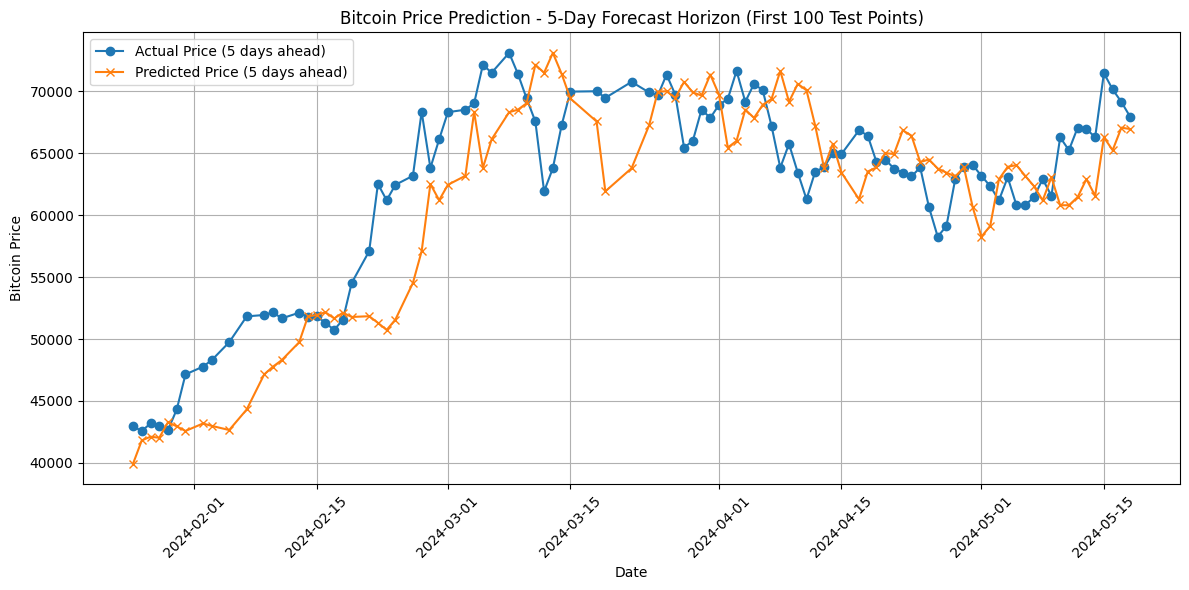


Best model expression:
X0

Sample predictions (5-day forecast horizon):
Date | Actual Price | Predicted Price | Error (%)
------------------------------------------------------------
2024-01-25 | $42952.61 | $39933.81 | -7.03%
2024-05-13 | $66940.80 | $62901.45 | -6.03%
2024-08-16 | $61175.19 | $58894.11 | -3.73%
2024-11-18 | $97777.28 | $90542.64 | -7.40%
2025-02-21 | $84347.02 | $96125.55 | 13.96%

Predicted price for the next day after 2025-02-26: $84347.02
Note: For a proper 5-day forecast, features would need to be updated for each prediction day.

Feature importance analysis:
Model expression: X0

Features used in the model (by frequency):
close: 1 occurrences


In [2]:
import pandas as pd
import numpy as np
from gplearn.genetic import SymbolicRegressor
from gplearn.functions import make_function
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv('bitcoin_processed_with_features.csv')
df['date'] = pd.to_datetime(df['date'])

df['EMA_20'] = df['close'].ewm(span=20, adjust=False).mean()
df['Momentum'] = df['close'] - df['close'].shift(10)
df['SMA_50'] = df['close'].rolling(window=50).mean()
df['SMA_100'] = df['close'].rolling(window=100).mean()

df['sentiment_impact'] = (
    df['positive_ratio'] * 1 -
    df['negative_ratio'] * 1 +
    df['neutral_ratio'] * 0.2
)
df['sentiment_rolling'] = df['sentiment_impact'].rolling(window=3).mean().fillna(0)

for lag in range(1, 6):
    df[f'close_lag_{lag}'] = df['close'].shift(lag)

df.fillna(0, inplace=True)

features = [
    'close', 'high', 'low', 'open', 'volume',
    'sentiment_impact', 'sentiment_rolling',
    'SMA_20', 'EMA_20', 'RSI', 'Bollinger_Upper', 'Bollinger_Lower',
    'Volatility', 'SMA_50', 'SMA_100', 'Momentum',
]

FORECAST_HORIZON = 5

X = df[features]
y = df['close'].shift(-FORECAST_HORIZON)
dates = df['date']

X = X[:-FORECAST_HORIZON]
y = y[:-FORECAST_HORIZON]
dates = dates[:-FORECAST_HORIZON]

train_mask = dates < '2024-01-01'
test_mask = dates >= '2024-01-01'

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
dates_test = dates[test_mask]

print(f"Training from {dates[train_mask].min().date()} to {dates[train_mask].max().date()}")
print(f"Testing  from {dates_test.min().date()} to {dates_test.max().date()}")

def protected_log(x):
    return np.where(x > 0, np.log(x), 0.0)

def protected_sqrt(x):
    return np.sqrt(np.abs(x))

def protected_exp(x):
    return np.where(x < 100, np.exp(x), 0.0)

def protected_sin(x):
    return np.sin(x)

def protected_cos(x):
    return np.cos(x)

log_func = make_function(function=protected_log, name="log", arity=1)
sqrt_func = make_function(function=protected_sqrt, name="sqrt", arity=1)
exp_func = make_function(function=protected_exp, name="exp", arity=1)
sin_func = make_function(function=protected_sin, name="sin", arity=1)
cos_func = make_function(function=protected_cos, name="cos", arity=1)

function_set = ['add', 'sub', 'mul', 'div', log_func, sqrt_func, exp_func, sin_func, cos_func]

model = SymbolicRegressor(
    function_set=function_set,
    population_size=1500,
    generations=50,
    stopping_criteria=0.01,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=0.9,
    verbose=1,
    parsimony_coefficient=0.001,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Actual price range in test: {y_test.min():.2f} to {y_test.max():.2f}")
print(f"Predicted price range     : {y_pred.min():.2f} to {y_pred.max():.2f}")

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(dates_test[:100], y_test.values[:100], label='Actual Price (5 days ahead)', marker='o')
plt.plot(dates_test[:100], y_pred[:100], label='Predicted Price (5 days ahead)', marker='x')
plt.title('Bitcoin Price Prediction - 5-Day Forecast Horizon (First 100 Test Points)')
plt.xlabel('Date')
plt.ylabel('Bitcoin Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nBest model expression:")
print(str(model._program))

sample_indices = np.linspace(0, len(dates_test) - 1, 5, dtype=int)
print("\nSample predictions (5-day forecast horizon):")
print("Date | Actual Price | Predicted Price | Error (%)")
print("-" * 60)
for idx in sample_indices:
    actual = y_test.iloc[idx]
    pred = y_pred[idx]
    error_pct = ((pred - actual) / actual) * 100
    print(f"{dates_test.iloc[idx].date()} | ${actual:.2f} | ${pred:.2f} | {error_pct:.2f}%")

if len(df) > 0:
    last_data = df.iloc[-1:][features]

    next_day_pred = model.predict(last_data)[0]
    print(f"\nPredicted price for the next day after {df['date'].iloc[-1].date()}: ${next_day_pred:.2f}")

    print("Note: For a proper 5-day forecast, features would need to be updated for each prediction day.")

if hasattr(model, '_program'):
    print("\nFeature importance analysis:")
    feature_indices = {}
    for i, feature in enumerate(features):
        feature_indices[f"X{i}"] = feature

    program_str = str(model._program)
    print(f"Model expression: {program_str}")

    feature_count = {}
    for feature_idx, feature_name in feature_indices.items():
        feature_count[feature_name] = program_str.count(feature_idx)

    sorted_features = sorted(feature_count.items(), key=lambda x: x[1], reverse=True)

    print("\nFeatures used in the model (by frequency):")
    for feature, count in sorted_features:
        if count > 0:
            print(f"{feature}: {count} occurrences")